# 02 — L'effet générique : autopsie de Cymbalta

**Objectif** : mesurer comment un médicament mature perd sa valeur commerciale
après l'arrivée des génériques, et distinguer ce que les données montrent
réellement de ce qu'un simple indicateur administratif suggère.

**Contexte réel** (hors dataset, pour cadrer l'analyse) :
le brevet européen du Cymbalta (duloxétine) a expiré fin 2012, la protection des
données a couru jusqu'à août 2014, et les premiers génériques français
(ex. Duloxétine Biogaran) ont été commercialisés fin 2015. Notre fenêtre de
données (2016–2025) **commence donc juste après le choc initial** : on observe
la queue de la substitution générique, pas son déclenchement.

*Sources : [DrugPatentWatch — Cymbalta](https://www.drugpatentwatch.com/p/tradename/CYMBALTA),
base de données publique des médicaments (déclaration de commercialisation Duloxétine Biogaran, 07/10/2015).*


## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

COULEUR_CYMBALTA = '#CC79A7'   # même couleur que dans le notebook 01
COULEUR_BAISSE   = '#CC79A7'
COULEUR_HAUSSE   = '#999999'

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_FILE   = PROJECT_DIR / 'data' / 'eli_lilly.csv'
OUTPUTS_DIR = PROJECT_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_FILE)
cym = df[df['nom_lilly'] == 'Cymbalta']
print(f'{cym.shape[0]:,} lignes Cymbalta, {cym["annee"].min()}–{cym["annee"].max()}')

5,084 lignes Cymbalta, 2016–2025


---
## 1. La double érosion : volume et prix

Deux courbes distinctes (jamais un double axe) : le volume de boîtes remboursées
et le coût moyen par boîte, chacun sur sa propre échelle.

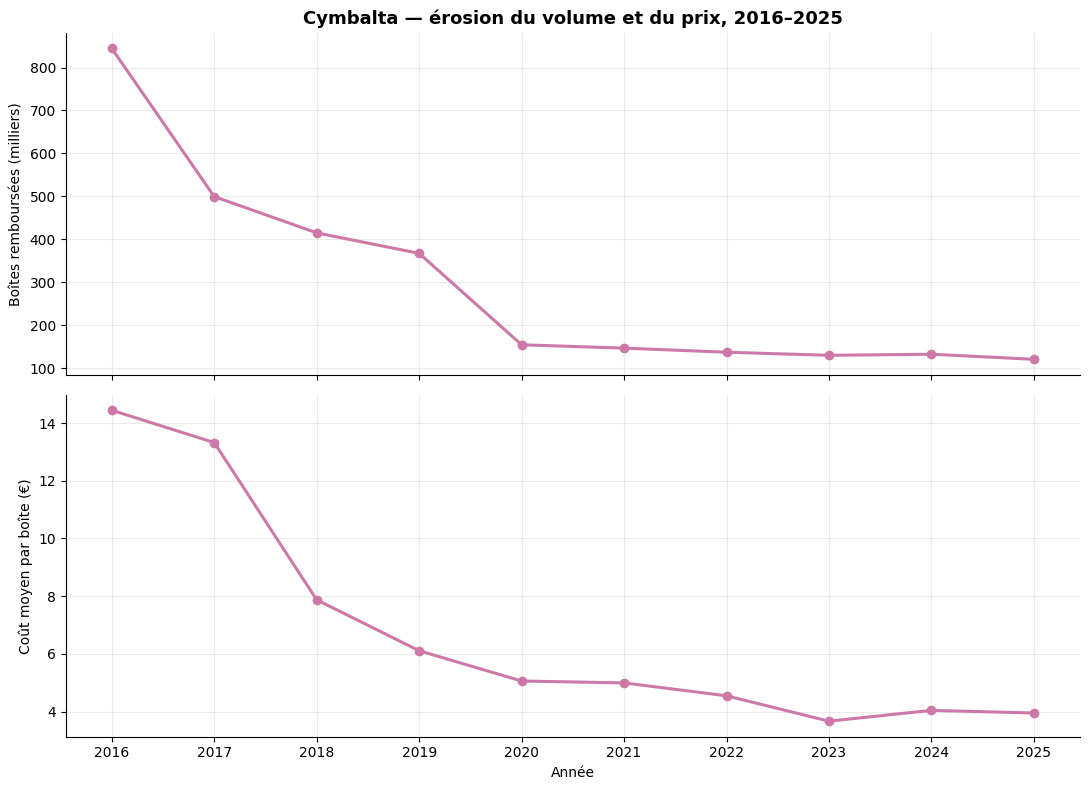

Volume : 844,535 → 121,014 boîtes (-86 %)
Prix   : 14.44 € → 3.95 € par boîte (-73 %)


In [2]:
evo = cym.groupby('annee').agg(rem=('rem', 'sum'), boites=('boites', 'sum'))
evo['cout_boite'] = evo['rem'] / evo['boites']

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(evo.index, evo['boites'] / 1e3, marker='o', markersize=6,
             linewidth=2.2, color=COULEUR_CYMBALTA)
axes[0].set_ylabel('Boîtes remboursées (milliers)')
axes[0].set_title('Cymbalta — érosion du volume et du prix, 2016–2025', fontsize=13, fontweight='bold')

axes[1].plot(evo.index, evo['cout_boite'], marker='o', markersize=6,
             linewidth=2.2, color=COULEUR_CYMBALTA)
axes[1].set_ylabel('Coût moyen par boîte (€)')
axes[1].set_xlabel('Année')
axes[1].set_xticks(evo.index)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'erosion_cymbalta.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Volume : {evo['boites'].iloc[0]:,.0f} → {evo['boites'].iloc[-1]:,.0f} boîtes "
      f"({(evo['boites'].iloc[-1]/evo['boites'].iloc[0]-1)*100:.0f} %)")
print(f"Prix   : {evo['cout_boite'].iloc[0]:.2f} € → {evo['cout_boite'].iloc[-1]:.2f} € par boîte "
      f"({(evo['cout_boite'].iloc[-1]/evo['cout_boite'].iloc[0]-1)*100:.0f} %)")

**Lecture.** Le volume est divisé par 7 et le prix par boîte par 3,6 en dix ans.
Mais la décroissance n'est pas un simple palier : il faut regarder d'année en
année pour localiser où se concentre vraiment le choc.

---
## 2. Où est le vrai choc ? Les données contre l'étiquette administrative

Open Medic fournit un champ `top_gen` qui indique le statut d'un médicament dans
le répertoire des génériques. Dans nos données, **les boîtes de Cymbalta
basculent de `top_gen = 0` à `top_gen = 4` en 2022** — un jury pourrait donc
supposer que « l'effet générique » date de 2022.

Regardons plutôt les **variations année par année** du volume et du prix : elles
racontent une histoire différente.

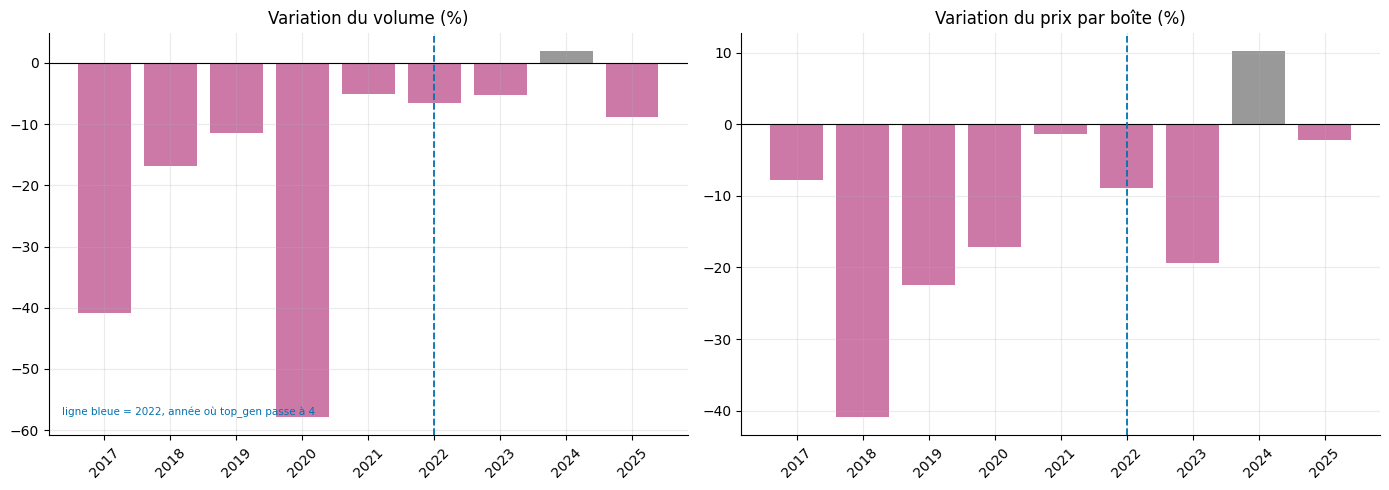

Plus forte baisse de VOLUME : 2020 (-58 %)
Plus forte baisse de PRIX   : 2018 (-41 %)


In [3]:
var = pd.DataFrame({
    'var_boites_pct':    evo['boites'].pct_change() * 100,
    'var_cout_pct':      evo['cout_boite'].pct_change() * 100,
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titre in zip(axes, ['var_boites_pct', 'var_cout_pct'],
                          ['Variation du volume (%)', 'Variation du prix par boîte (%)']):
    couleurs = [COULEUR_BAISSE if v < 0 else COULEUR_HAUSSE for v in var[col]]
    ax.bar(var.index.astype(str), var[col], color=couleurs)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titre)
    ax.tick_params(axis='x', rotation=45)
    # Repère : l'année où top_gen bascule à 4 dans nos données
    if 2022 in var.index:
        idx = list(var.index).index(2022)
        ax.axvline(idx, color='#0072B2', linestyle='--', linewidth=1.3)

axes[0].text(0.02, 0.05, 'ligne bleue = 2022, année où top_gen passe à 4',
             transform=axes[0].transAxes, fontsize=7.5, color='#0072B2')

plt.tight_layout()
plt.show()

annee_choc_volume = var['var_boites_pct'].idxmin()
annee_choc_prix    = var['var_cout_pct'].idxmin()
print(f"Plus forte baisse de VOLUME : {annee_choc_volume} ({var.loc[annee_choc_volume,'var_boites_pct']:.0f} %)")
print(f"Plus forte baisse de PRIX   : {annee_choc_prix} ({var.loc[annee_choc_prix,'var_cout_pct']:.0f} %)")

**Lecture — décalage entre l'étiquette et la réalité économique.** Le plus fort
recul de **prix** a lieu en **2018** (−41 %), quatre ans avant que `top_gen`
ne signale une bascule. Le plus fort recul de **volume** a lieu en **2020**
(−58 %) — année de la Covid-19, où les consultations et primo-prescriptions
d'antidépresseurs ont chuté partout, pas seulement pour Cymbalta ; ce point est
probablement confondu avec l'effet pandémique, pas uniquement générique.

**Conclusion méthodologique** : un indicateur administratif comme `top_gen` ne
capture pas nécessairement le moment réel de la rupture de marché. Les séries de
volume et de prix sont des mesures plus fiables du choc économique que le champ
de classification lui-même.

---
## 3. Décomposition volume × prix (2016 → 2025)

Même méthode que dans le notebook 01 : on sépare la variation totale des
remboursements entre effet volume et effet prix.

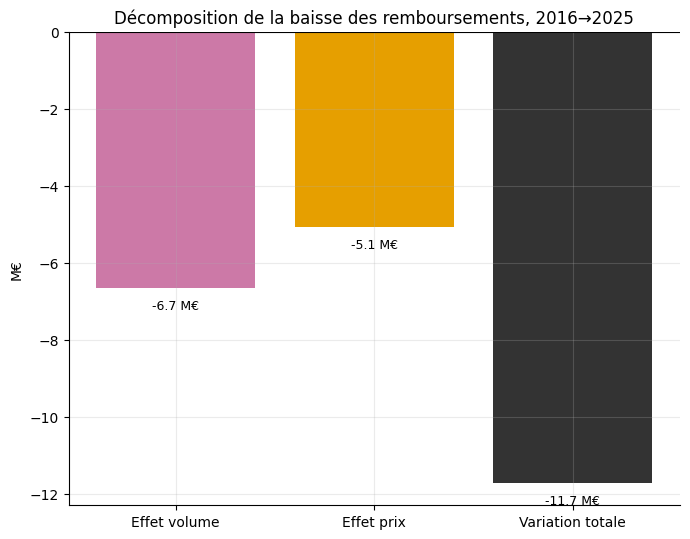

Variation totale 2016→2025 : -11.7 M€
  dont effet volume : -6.7 M€ (57 % de la baisse)
  dont effet prix   : -5.1 M€ (43 % de la baisse)


In [4]:
a0, a1 = evo.index.min(), evo.index.max()
q0, q1 = evo.loc[a0, 'boites'], evo.loc[a1, 'boites']
p0, p1 = evo.loc[a0, 'cout_boite'], evo.loc[a1, 'cout_boite']

effet_volume = (p0 + p1) / 2 * (q1 - q0)
effet_prix   = (q0 + q1) / 2 * (p1 - p0)
delta_rem    = evo.loc[a1, 'rem'] - evo.loc[a0, 'rem']

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.bar(['Effet volume', 'Effet prix', 'Variation totale'],
       [effet_volume / 1e6, effet_prix / 1e6, delta_rem / 1e6],
       color=[COULEUR_CYMBALTA, '#E69F00', '#333333'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('M€')
ax.set_title(f'Décomposition de la baisse des remboursements, {a0}→{a1}')
for i, v in enumerate([effet_volume / 1e6, effet_prix / 1e6, delta_rem / 1e6]):
    ax.text(i, v - 0.3 if v < 0 else v + 0.1, f'{v:.1f} M€', ha='center',
            va='top' if v < 0 else 'bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Variation totale {a0}→{a1} : {delta_rem/1e6:.1f} M€')
print(f'  dont effet volume : {effet_volume/1e6:.1f} M€ ({effet_volume/delta_rem*100:.0f} % de la baisse)')
print(f'  dont effet prix   : {effet_prix/1e6:.1f} M€ ({effet_prix/delta_rem*100:.0f} % de la baisse)')

**Lecture.** La baisse des remboursements de Cymbalta est une **double peine** :
contrairement aux produits en croissance du notebook 01 (portés par le seul
volume), ici le volume ET le prix reculent simultanément — la signature typique
d'un princeps après l'arrivée de ses génériques.

---
## 4. Contrefactuel : combien la baisse de prix a-t-elle fait économiser ?

**Question** : si le prix par boîte de Cymbalta était resté à son niveau de
2016 (14,44 €), combien l'Assurance Maladie aurait-elle payé chaque année pour
le **volume réellement consommé** ?

$$\text{Remboursement contrefactuel}_{t} = \text{Boîtes réelles}_{t} \times \text{Prix}_{2016}$$

**Attention à l'interprétation** : ceci isole le seul effet prix (le volume réel
est conservé tel quel). Ce n'est **pas** un scénario "sans générique" — dans un
monde sans substitution, le volume lui-même aurait probablement été différent.
C'est un exercice comptable simple, pas une estimation causale.

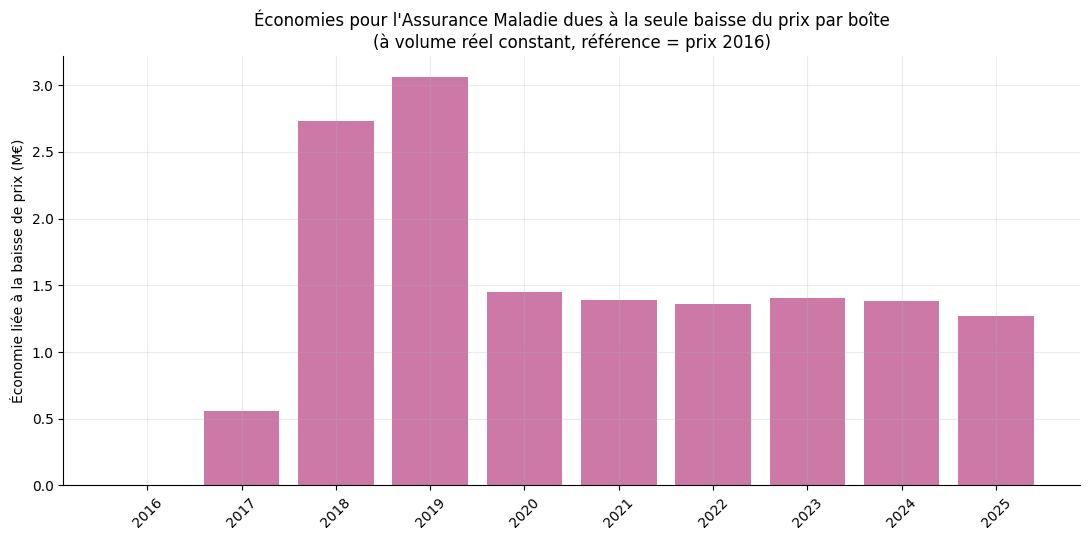

Économie cumulée 2017–2025 (effet prix seul) : 14.6 M€
Pour comparaison, le remboursement réel cumulé 2017–2025 : 15.8 M€


In [5]:
prix_2016 = evo.loc[2016, 'cout_boite']
evo['rem_contrefactuel'] = evo['boites'] * prix_2016
evo['economie_prix']     = evo['rem_contrefactuel'] - evo['rem']

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(evo.index.astype(str), evo['economie_prix'] / 1e6, color=COULEUR_CYMBALTA)
ax.set_ylabel('Économie liée à la baisse de prix (M€)')
ax.set_title('Économies pour l\'Assurance Maladie dues à la seule baisse du prix par boîte\n(à volume réel constant, référence = prix 2016)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

economie_cumulee = evo.loc[2017:, 'economie_prix'].sum()
print(f'Économie cumulée 2017–2025 (effet prix seul) : {economie_cumulee/1e6:.1f} M€')
print(f'Pour comparaison, le remboursement réel cumulé 2017–2025 : {evo.loc[2017:, "rem"].sum()/1e6:.1f} M€')

**Lecture.** Rien que par la baisse du prix (sans compter la chute du volume),
l'Assurance Maladie a évité de dépenser plusieurs dizaines de M€ sur ce seul
médicament. Une limite importante : ce chiffre ne concerne que le Cymbalta
**marque** — il ne dit rien du montant réellement dépensé en génériques de
duloxétine, absents de ce dataset (voir limites du projet).

---
## 5. Synthèse et export

**Ce qu'il faut retenir :**
- Le déclin de Cymbalta combine effondrement du **volume** et du **prix** — à
  la différence des produits en croissance (notebook 01), portés par le seul volume.
- Le vrai choc de prix se situe en **2018**, pas en 2022 comme le suggérait le
  champ administratif `top_gen` : un indicateur de classification n'est pas un
  indicateur d'événement de marché.
- La chute de volume de 2020 coïncide avec la Covid-19 — probable confusion
  entre effet générique et effet pandémique, à mentionner comme limite.
- Le mécanisme isolé de baisse de prix a permis, à lui seul, d'éviter environ
  15 M€ de remboursements cumulés sur 2017–2025 (exercice comptable, pas causal).

In [6]:
export = evo.reset_index()[['annee', 'rem', 'boites', 'cout_boite',
                           'rem_contrefactuel', 'economie_prix']]
export_path = OUTPUTS_DIR / 'effet_generique_cymbalta.csv'
export.to_csv(export_path, index=False, encoding='utf-8')
print(f'Exporté : {export_path} ({export.shape[0]} lignes)')
export.round(2)

Exporté : c:\Users\Enes\Desktop\projet_lilly\outputs\effet_generique_cymbalta.csv (10 lignes)


,annee,rem,boites,cout_boite,rem_contrefactuel,economie_prix
0,2016,12197916.45,844535,14.44,12197916.45,0.00
1,2017,6656894.88,499646,13.32,7216563.15,559668.27
2,2018,3269003.33,415250,7.87,5997602.00,2728598.67
3,2019,2245043.68,367542,6.11,5308538.55,3063494.87
4,2020,783140.21,154801,5.06,2235845.36,1452705.15
5,2021,734162.40,147028,4.99,2123577.19,1389414.79
6,2022,625298.37,137519,4.55,1986235.35,1360936.98
7,2023,477686.03,130270,3.67,1881535.49,1403849.46
8,2024,536669.69,132794,4.04,1917990.51,1381320.82
9,2025,478021.27,121014,3.95,1747847.82,1269826.55
